# Time Varying LQG, Part I: LQR

Gerry Chen, Frank Dellaert

## Introduction

This notebook series provides an interactive tutorial and example implementation of a Time-Varying Linear Quadratic Gaussian (TV-LQG) using GTSAM as described in the paper [Locally Optimal Estimation and Control of Cable Driven Parallel Robots using Time Varying Linear Quadratic Gaussian Control](https://gerry-chen.com/publications/chen22iros_cdpr_control/) [[doi](https://doi.org/10.1109/IROS47612.2022.9981144)], [[arXiv](https://arxiv.org/abs/2208.00916)].

Colloquially, the TV-LQG algorithm implements a tracking controller (with estimator) which is especially well-suited for systems where a PID controller (with Kalman Filter) would work well, if not for the fact that the system is sufficiently non-linear that a single set of PID gains would not work well across the entire workspace/trajectory.  Subjectively, out of the (very) small set of robot systems where PID controllers are not effective, this captures a large fraction of them.

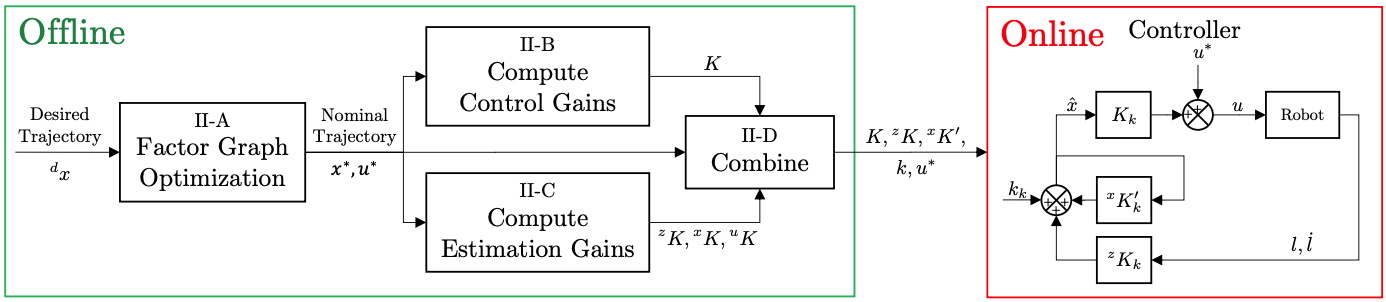

## Outline

We will implement the TV-LQG algorithm using GTSAM in three parts:
1. Linear Quadratic Regulator (LQR)
2. Kalman Filter (KF) and putting it together (KF + LQR = LQG)
3. Extending to nonlinear (TV-LQG)

This notebook will cover just the first part.

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop//Users/gerry/GIT_REPOS/gtsam/python/gtsam/notebooks/TimeVaryingLQG_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2022, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

# Part I: LQR

We first show the finite-horizon LQR problem can be solved using GTSAM.  For additional detail, see [LQR Control Using Factor Graphs](https://gtsam.org/2019/11/07/lqr-control.html) or [Equality Constrained Linear Optimal Control With Factor Graphs](https://gerry-chen.com/publications/yang21pre_eclqr/) [[doi](https://doi.org/10.1109/ICRA48506.2021.9562000)] [[arXiv](https://arxiv.org/abs/2011.01360)].

The finite-horizon LQR problem can be formulated as follows:

$$\begin{aligned}
\min_{\bm{x}, \bm{u}} & \sum_{k=0}^{N-1} \left( x_k^T Q_k x_k + u_k^T R_k u_k \right) + x_N^T Q_N x_N \\
\text{subject to } & x_{k+1} = A_k x_k + B_k u_k, \quad k = 0, \ldots, N-1 \\
& x_0 = x_{\text{init}}
\end{aligned}$$

where:
- $x_k$ is the state vector at time $k$
- $u_k$ is the control input vector at time $k$
- $A_k$ and $B_k$ are the system dynamics matrices at time $k$
- $Q_k$ and $R_k$ are the state and control cost matrices at time $k$
- $N$ is the time horizon

Classically, we can solve this problem using dynamic programming and the Riccati equation. However, we can also formulate this as a least-squares problem and solve it using GTSAM.

Let's create a simple example with the following parameters representing a second-order linear system with acceleration as control input, and position error + control effort minimization objectives:
$$\begin{aligned}
A &= \begin{bmatrix} 1 & dt \\ 0 & 1 \end{bmatrix}, \quad B = \begin{bmatrix} 0.5 \cdot dt^2 \\ dt \end{bmatrix} \\
Q &= \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix}, \quad R = \begin{bmatrix} 1 \end{bmatrix}, \quad Q_{T} = \begin{bmatrix} 10 & 0 \\ 0 & 0 \end{bmatrix}
\end{aligned}$$

In [2]:
import dataclasses
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from graphviz import Source # for dot file visualization

import gtsam
from gtsam import GaussianFactorGraph, JacobianFactor, GaussianBayesNet, Ordering, Symbol
from gtsam.noiseModel import Gaussian, Constrained
from gtsam.symbol_shorthand import X, U

N = 100
dt = 0.03
A = np.array([
    [1.0, dt],
    [0.0, 1.0],
])
B = np.array([
    [0.5 * dt * dt],
    [dt],
])
Q = np.diag([50.0, 0.0])  # aggressive position cost, no velocity cost
Qfinal = Q * 10.0  # large terminal cost can help prevent "cutting corners" at the end
R = np.diag([1.0])  # modest control effort cost
x0 = np.array([3.0, 0.0])  # start out at position 3 at rest

## A. Defining the factor graph

First, recognize that maximizing gaussian distributions is equivalent to minimizing linear least squares.  Thus any quadratic objective term can be equivalently represented in GTSAM as a Gaussian factor.  In this example,

$$\begin{aligned}
\arg\min_{x, u} ~~\sum_{k=0}^{N-1} \left( x_k^T Q x_k + u_k^T R u_k \right) + x_T^T Q_{T} x_T
    % &= \arg\max_{x, u} ~~\exp\left(-\frac{1}{2} \left( \sum_{k=0}^{N-1} \left( x_k^T Q x_k + u_k^T R u_k \right) + x_T^T Q_{T} x_T \right)\right) \\
    % &= \arg\max_{x, u} ~~\prod_k^{N-1} \exp\left(-\frac{1}{2}\left( x_k^T Q x_k\right)\right) \cdot \prod_k^{N-1} \exp\left(-\frac{1}{2}\left(u_k^T R u_k \right)\right) \cdot \exp\left(-\frac{1}{2}\left(x_T^T Q_T x_T \right)\right) \\
    &= \arg\max_{x, u} ~~\prod_k^{N-1} \mathcal{N}(x_k | 0, Q_k^{-1}) \cdot \prod_k^{N-1} \mathcal{N}(u_k | 0, R_k^{-1}) \cdot \mathcal{N}(x_T | 0, Q_N^{-1})
\end{aligned}$$
where $\mathcal{N}(\cdot | \mu, \Sigma)$ denotes the pdf of a gaussian with mean $\mu$ and covariance $\Sigma$ evaluated at $\cdot$.

Constraints can similarly be added as Gaussian factors with very small covariance, or "zero-covariance".  GTSAM handles "zero-covariance" linear constraints gracefully (see [LQR Control Using Factor Graphs](https://gtsam.org/2019/11/07/lqr-control.html) or [Equality Constrained Linear Optimal Control With Factor Graphs](https://gerry-chen.com/publications/yang21pre_eclqr/) for some additional background on this).

In [3]:
factor_graph = GaussianFactorGraph()
# Add optimization objectives
for k in range(N):
    factor_graph.add(X(k), np.eye(2), np.zeros(2), Gaussian.Information(Q))  # ||x - 0||^2_Qinv
    factor_graph.add(U(k), np.eye(1), np.zeros(1), Gaussian.Information(R))  # ||u - 0||^2_Rinv
factor_graph.add(X(N), np.eye(2), np.zeros(2), Gaussian.Information(Qfinal)) # terminal cost

# Add dynamics constraints
for k in range(N):
    factor_graph.add(
        X(k), -A,
        U(k), -B,
        X(k + 1), np.eye(2),
        np.zeros(2),
        Constrained.All(2)  # perfect dynamics constraints
    )

# Add initial state
factor_graph.add(
    X(0),
    np.eye(2),
    x0,
    Constrained.All(2)  # perfect initial state
)

## B. Solving for the open-loop solution

We can easily solve for the "open loop" solution using GTSAM:

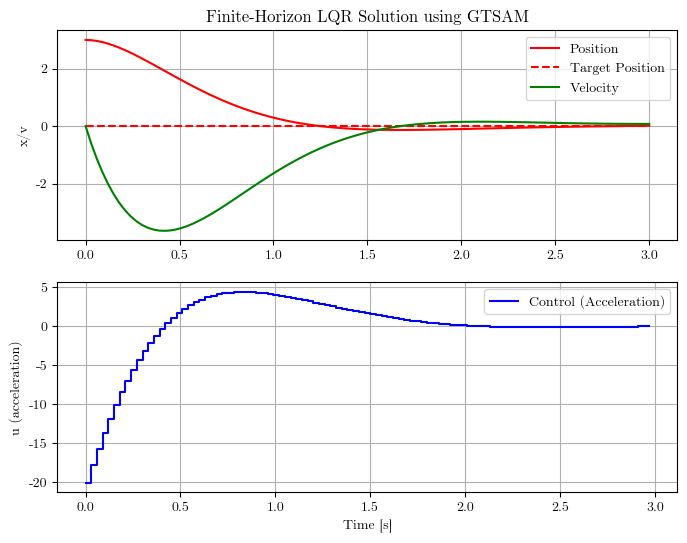

In [4]:
# Solve!
result = factor_graph.optimize()

# Plot results
ts = np.arange(N + 1) * dt
xs = np.array([result.at(X(i)) for i in range(N + 1)])
us = np.array([result.at(U(i)) for i in range(N)])
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax.plot(ts, xs[:, 0], 'r', label='Position')
ax.plot(ts, 0 * ts, 'r--', label='Target Position')
ax.plot(ts, xs[:, 1], 'g', label='Velocity')
ax2.step(ts[:-1], us[:, 0], 'b', where='post', label='Control (Acceleration)')
ax2.set_xlabel('Time [s]')
ax.set_ylabel('x/v')
ax2.set_ylabel('u (acceleration)')
ax.legend()
ax2.legend()
ax.set_title('Finite-Horizon LQR Solution using GTSAM');

## C. Solving for the closed-loop feedback law

That's great, but the real value of LQR is the **control law** that comes with it.  Subject to disturbances, it turns out the optimal control input at each time step can be expressed as a linear feedback of the state:

$$u_k^* = K_k x_k$$
where $K_k$ is the feedback gain matrix at time $k$.

Fortunately, factor graph elimination exactly recovers these gain matrices in the form of the Bayes Net.  For a quick intuition, eliminating a factor graph is equivalent to factorizing:

$$\begin{aligned}
 p(x_0, u_0, x_1, u_1, \ldots, x_N) &= p(x_N | x_{N-1}, u_{N-1}) \cdots p(u_1 | x_1) \cdot p(x_1 | x_0, u_0) \cdot p(u_0 | x_0) \cdot p(x_0)  \\
\end{aligned}$$

Then each term reads off the "optimal" value of the variable given its parents (aka forward-substitution).  For example, the Gaussian $p(u_k | x_k)$ tells us exactly what the optimal $u_k$ is given $x_k$, and because it is Gaussian, $u_k^*$ is a linear function of $x_k$.

In [5]:
# We want to eliminate in the order X*N, U*{N-1}, X\_{N-1}, ..., U_0, X_0
ordering = [X(N)]
for k in reversed(range(N)):
    ordering.append(U(k))
    ordering.append(X(k))
ordering = Ordering(ordering)
# Now eliminate
bayes_net = factor_graph.eliminateSequential(ordering)
# Visualize the Bayes Net
display(
    Source(bayes_net.dot().replace('size="5,5";',
                                   'size="50000,5"; rankdir=LR;')))

for i in range(bayes_net.size()):
    cond = bayes_net.at(i)
    keys = map(Symbol, cond.keys())  # Pretty-print keys
    keys = map(lambda k: str(k)[:-1], keys)  # Remove trailing newline
    print(f'Conditional {i}: p({next(keys)} | {", ".join(keys)})')
    if i > 10:
        print("...")
        break

Conditional 0: p(x100 | u99, x99)
Conditional 1: p(u99 | x99)
Conditional 2: p(x99 | u98, x98)
Conditional 3: p(u98 | x98)
Conditional 4: p(x98 | u97, x97)
Conditional 5: p(u97 | x97)
Conditional 6: p(x97 | u96, x96)
Conditional 7: p(u96 | x96)
Conditional 8: p(x96 | u95, x95)
Conditional 9: p(u95 | x95)
Conditional 10: p(x95 | u94, x94)
Conditional 11: p(u94 | x94)
...


Notice how each odd-indexed conditional corresponds to a control input $u_k$ given the state $x_k$.  We can extract the gain matrices from these conditionals as follows:

$$ p(u_k | x_k) \propto \exp \left(-\frac{1}{2} ||Ru_k + S_0 x_k - d||^2_\Sigma \right) $$

So the solution from back-substitution should be:

$$\begin{aligned}
 u_k^* &= (-R^{-1} S_0) x_k + (R^{-1} d) \\
         &= K_k x_k + k_k
 \end{aligned} $$

where $K_k = -R^{-1} S_0$ is the feedback gain matrix and $k_k = R^{-1} d$ is the feedforward term.

In [6]:
# Extract the gains
def extract_gain(gaussian_conditional):
    """Extract the gain matrix K from a GaussianConditional of the form
    p(u_k | x_k) => || Ru_k - S_0 x_k - d||^2_Sigma
    """
    K = scipy.linalg.solve_triangular(gaussian_conditional.R(),
                                      -gaussian_conditional.S())
    k = scipy.linalg.solve_triangular(gaussian_conditional.R(),
                                      gaussian_conditional.d())
    return K, k


gains = {}
for i in range(bayes_net.size()):
    cond = bayes_net.at(i)
    parent = Symbol(cond.firstFrontalKey())
    if parent.chr() == ord('u'):  # We only care about p(u_k | ...)
        K, k = extract_gain(cond)
        gains[parent.index()] = (K, k)

gains

{99: (array([[-0.22497722, -0.00674932]]), array([0.])),
 98: (array([[-0.69678972, -0.041133  ]]), array([0.])),
 97: (array([[-1.21062305, -0.10559097]]), array([0.])),
 96: (array([[-1.76198513, -0.20205192]]), array([0.])),
 95: (array([[-2.34384016, -0.33158814]]), array([0.])),
 94: (array([[-2.94642913, -0.49405262]]), array([0.])),
 93: (array([[-3.55738868, -0.68775659]]), array([0.])),
 92: (array([[-4.16225716, -0.90926209]]), array([0.])),
 91: (array([[-4.74539385, -1.1533655 ]]), array([0.])),
 90: (array([[-5.29123952, -1.4133235 ]]), array([0.])),
 89: (array([[-5.78574048, -1.68132442]]), array([0.])),
 88: (array([[-6.21768407, -1.94914555]]), array([0.])),
 87: (array([[-6.57968873, -2.20888448]]), array([0.])),
 86: (array([[-6.86866707, -2.4536302 ]]), array([0.])),
 85: (array([[-7.08571072, -2.67795889]]), array([0.])),
 84: (array([[-7.23548137, -2.87818965]]), array([0.])),
 83: (array([[-7.3252859 , -3.05239752]]), array([0.])),
 82: (array([[-7.36404201, -3.2

## D. Sanity checking

First, we see that the resulting control laws look roughly like:

$$ u_k^* = [K_1, K_2] x_k + 0 $$

where:
* $K_1$ and $K_2$ are both negative, indicating that positive $x_k$ means we should apply negative acceleration,
* $K_1$ is larger than $K_2$, indicating that position error is "worse" than velocity error,
* earlier timesteps have larger magnitude gains than later timesteps (which makes sense since earlier errors will compound over time more than later errors), and
* the "feedforward" term is zero, which makes sense since we are trying to stabilize the system to the origin.

These all make sense given our problem formulation.

We can further sanity check that our open-loop solution matches the closed-loop solution when there are no disturbances, and via closed-loop simulation with disturbances.

In [7]:
# First check open-loop solution matches closed-loop solution
assert all(np.isclose(k, 0)
           for K, k in gains.values()), "Feedforward term not 0"
Ks = np.concatenate([gains[i][0] for i in range(N)])
expected_us = np.einsum('ki,ki-> k', Ks, xs[:-1, :])
np.testing.assert_allclose(
    expected_us,
    us.flatten(),
    err_msg="Open loop solution does not match closed loop feedback law")
print("Open loop solution matches closed loop feedback law")

Open loop solution matches closed loop feedback law


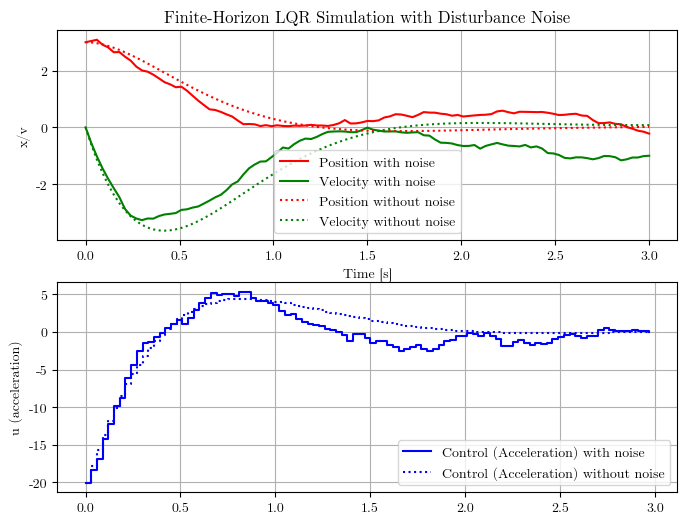

In [8]:
# Simulation with state disturbance noise x = Ax + Bu + v, v ~ N(0, 0.001 I)
noise = np.random.multivariate_normal(mean=np.zeros(2), cov=np.eye(2) * 0.1 * dt, size=N)
x_sim = np.zeros((N + 1, 2))
u_sim = np.zeros((N, 1))
x_sim[0] = x0
for i in range(N):
    K, k = gains[i]
    u_sim[i] = K @ x_sim[i] + k  # Include feedforward term
    x_sim[i + 1] = A @ x_sim[i] + B @ u_sim[i] + noise[i]

# Plot simulation results
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax.plot(ts, x_sim[:, 0], 'r-', label='Position with noise')
ax.plot(ts, x_sim[:, 1], 'g-', label='Velocity with noise')
ax.plot(ts, xs[:, 0], 'r:', label='Position without noise')
ax.plot(ts, xs[:, 1], 'g:', label='Velocity without noise')
ax2.step(ts[:-1], u_sim[:, 0], 'b-', where='post', label='Control (Acceleration) with noise')
ax2.step(ts[:-1], us[:, 0], 'b:', where='post', label='Control (Acceleration) without noise')
ax.set_xlabel('Time [s]')
ax.set_ylabel('x/v')
ax2.set_ylabel('u (acceleration)')
ax.legend()
ax2.legend()
ax.set_title('Finite-Horizon LQR Simulation with Disturbance Noise');

## E. Non-zero setpoint ("trajectory") tracking controller

It is straightforward in GTSAM to track non-zero reference trajectories and non-zero "desired" control inputs:

$$\begin{aligned}
\min_{\bm{x}, \bm{u}} & \sum_{k=0}^{N-1} \left( (x_k - \tilde{x}_k)^T Q_k (x_k - \tilde{x}_k) + (u_k - \tilde{u}_k)^T R_k (u_k - \tilde{u}_k) \right) + (x_N - \tilde{x}_N)^T Q_N (x_N - \tilde{x}_N) \\
\text{subject to } & x_{k+1} = A_k x_k + B_k u_k, \quad k = 0, \ldots, N-1 \\
& x_0 = x_{\text{init}}
\end{aligned}$$

Basically, we just add a "mean" term to each Gaussian factor representing the cost terms.

In [9]:
xref = np.stack([3 * np.sin(ts), np.zeros_like(ts)], axis=1)
uref = np.zeros((N, 1))

## F. Minimal LQR implementation example, 26 lines!
The following 26 lines shows a complete LQR implementation in GTSAM, including trajectory tracking.

In [10]:
@dataclasses.dataclass
class FeedbackLaw:
    K: np.ndarray
    k: np.ndarray

    def apply(self, x):
        return self.K @ x + self.k

In [11]:
# Create Factor Graph
gfg = GaussianFactorGraph()
for k in range(N):
    gfg.add(X(k), np.eye(2), xref[k], Gaussian.Information(Q))  # state cost
    gfg.add(U(k), np.eye(1), uref[k], Gaussian.Information(R))  # control cost
gfg.add(X(N), np.eye(2), xref[N], Gaussian.Information(Qfinal))  # final cost
for k in range(N):  # dynamics constraints
    gfg.add(X(k), -A, U(k), -B, X(k + 1), np.eye(2), np.zeros(2),
            Constrained.All(2))
gfg.add(X(0), np.eye(2), x0, Constrained.All(2))  # initial state

# Solve open-loop solution
open_loop_result = gfg.optimize()
xs = np.array([open_loop_result.at(X(i)) for i in range(N + 1)])
us = np.array([open_loop_result.at(U(i)) for i in range(N)])

# Extract closed-loop feedback law gains
bayes_net = gfg.eliminateSequential(ordering)
feedback_gains = [None] * N
for k in range(bayes_net.size()):
    cond = bayes_net.at(k)
    parent = Symbol(cond.firstFrontalKey())
    if parent.chr() == ord('u'):
        K = scipy.linalg.solve_triangular(cond.R(), -cond.S())
        k = scipy.linalg.solve_triangular(cond.R(), cond.d())
        feedback_gains[parent.index()] = FeedbackLaw(K, k)

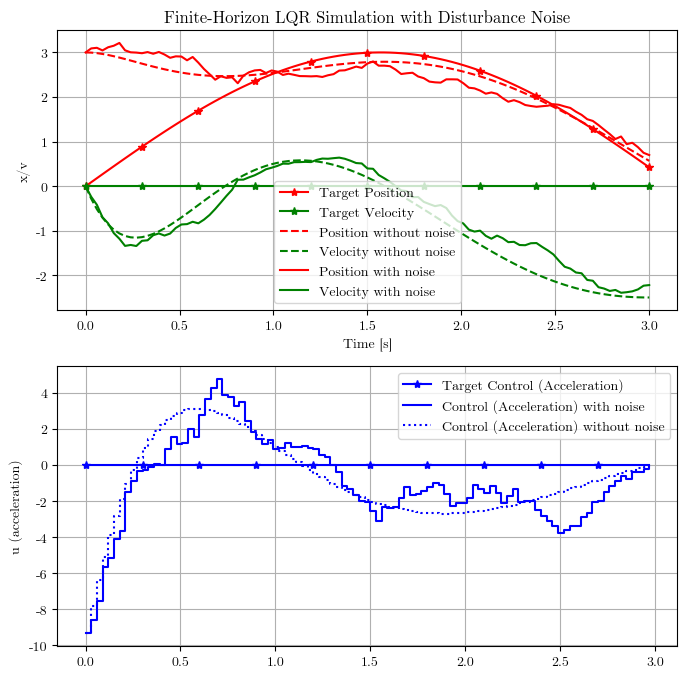

In [12]:
# Validation!

# Basic sanity check
assert all(feedback_gains), "Some feedback gains are missing"

# Check open-loop solution matches closed-loop feedback law
exp_us = np.array([
    feedback_law.apply(x) for feedback_law, x in zip(feedback_gains, xs[:-1])
])
np.testing.assert_allclose(exp_us, us)

# Simulation
noise = np.random.multivariate_normal(mean=np.zeros(2),
                                      cov=np.eye(2) * 0.1 * dt,
                                      size=N)
x_sim = np.zeros((N + 1, 2))
u_sim = np.zeros((N, 1))
x_sim[0] = x0
for i in range(N):
    u_sim[i] = feedback_gains[i].apply(x_sim[i])
    x_sim[i + 1] = A @ x_sim[i] + B @ u_sim[i] + noise[i]

# Plot open-loop and closed-loop simulation results
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 8))
setpoint_opts = dict(linestyle='-', marker='*', markevery=10)
ax.plot(ts, xref[:, 0], 'r', **setpoint_opts, label='Target Position')
ax.plot(ts, xref[:, 1], 'g', **setpoint_opts, label='Target Velocity')
ax.plot(ts, xs[:, 0], 'r--', label='Position without noise')
ax.plot(ts, xs[:, 1], 'g--', label='Velocity without noise')
ax.plot(ts, x_sim[:, 0], 'r-', label='Position with noise')
ax.plot(ts, x_sim[:, 1], 'g-', label='Velocity with noise')
ax2.plot(ts[:-1],
         uref[:, 0],
         'b',
         **setpoint_opts,
         label='Target Control (Acceleration)')
ax2.step(ts[:-1],
         u_sim[:, 0],
         'b-',
         where='post',
         label='Control (Acceleration) with noise')
ax2.step(ts[:-1],
         us[:, 0],
         'b:',
         where='post',
         label='Control (Acceleration) without noise')
ax.set_xlabel('Time [s]')
ax.set_ylabel('x/v')
ax2.set_ylabel('u (acceleration)')
ax.legend()
ax2.legend()
ax.set_title('Finite-Horizon LQR Simulation with Disturbance Noise');

In the above plot, we see that, despite the initial state being far from the reference trajectory, the LQR controller quickly converges to tracking the desired trajectory closely.

We can also see how modifying the cost weights affects the solution:

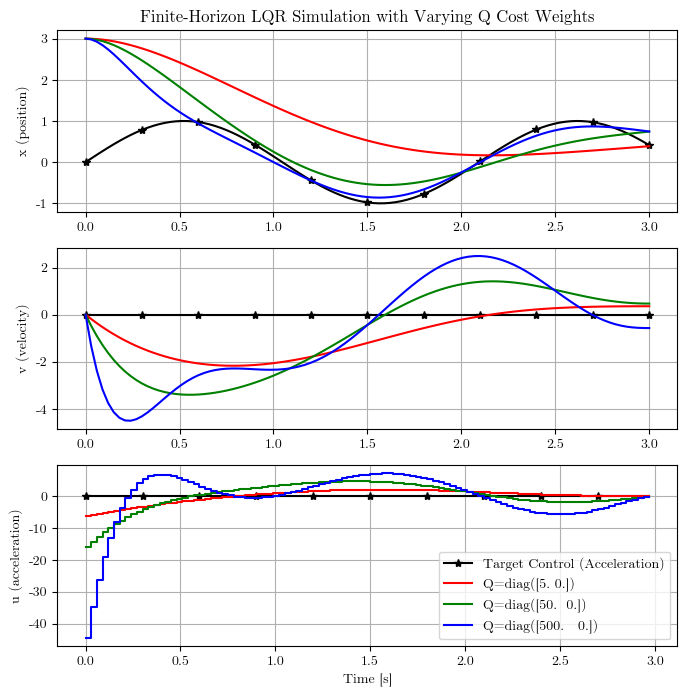

In [13]:
xref = np.stack([np.sin(ts * 3), np.zeros_like(ts)], axis=1)
uref = np.zeros((N, 1))

def solve_open_loop(Q):
    # Create Factor Graph
    gfg = GaussianFactorGraph()
    for k in range(N):
        gfg.add(X(k), np.eye(2), xref[k],
                Gaussian.Information(Q))  # state cost
        gfg.add(U(k), np.eye(1), uref[k],
                Gaussian.Information(R))  # control cost
    gfg.add(X(N), np.eye(2), xref[N],
            Gaussian.Information(Qfinal))  # final cost
    for k in range(N):  # dynamics constraints
        gfg.add(X(k), -A, U(k), -B, X(k + 1), np.eye(2), np.zeros(2),
                Constrained.All(2))
    gfg.add(X(0), np.eye(2), x0, Constrained.All(2))  # initial state

    # Solve open-loop solution
    open_loop_result = gfg.optimize()
    xs = np.array([open_loop_result.at(X(i)) for i in range(N + 1)])
    us = np.array([open_loop_result.at(U(i)) for i in range(N)])
    return xs, us


def add_to_plot(axes, xs, us, linestyle, label):
    axes[0].plot(ts, xs[:, 0], linestyle, label=label)
    axes[1].plot(ts, xs[:, 1], linestyle, label=label)
    axes[2].step(ts[:-1], us[:, 0], linestyle, where='post', label=label)


fig, axes = plt.subplots(3, 1, figsize=(8, 8))
setpoint_opts = dict(color='k', linestyle='-', marker='*', markevery=10)
axes[0].plot(ts, xref[:, 0], **setpoint_opts, label='Target Position')
axes[1].plot(ts, xref[:, 1], **setpoint_opts, label='Target Velocity')
axes[2].plot(ts[:-1],
             uref[:, 0],
             **setpoint_opts,
             label='Target Control (Acceleration)')

for q_scale, linestyle in [(0.1, 'r-'), (1.0, 'g-'), (10.0, 'b-')]:
    xs, us = solve_open_loop(Q * q_scale)
    add_to_plot(axes, xs, us, linestyle=linestyle, label=f'Q=diag({np.diag(Q) * q_scale})')

axes[2].set_xlabel('Time [s]')
axes[0].set_ylabel('x (position)')
axes[1].set_ylabel('v (velocity)')
axes[2].set_ylabel('u (acceleration)')
axes[2].legend()
axes[0].set_title('Finite-Horizon LQR Simulation with Varying Q Cost Weights');

## F. Next: Part II - Kalman Filter and LQG

We will show how to use GTSAM to obtain Kalman Filter gain matrices.